# Check results of DFT as they come out

In [1]:
import os
import re
import copy
import numpy as np
import glob
import sys
import ase

import rmgpy.chemkin
import rmgpy.kinetics
import rmgpy.tools.uncertainty


import arkane.modelchem
import arkane.ess
import arkane.encorr
import arkane.common

DFT_DIR = os.path.join(os.environ['AUTOSCIENCE_REPO'], 'dft')
sys.path.append(DFT_DIR)
import autotst_wrapper

sys.path.append(os.environ['DATABASE_DIR'])
import database_fun


import matplotlib.pyplot as plt
%matplotlib inline

/home/harris.se/rmg/RMG-Py/rmgpy/rmg/reactors.py:53: RuntimeWarning: Unable to import Julia dependencies, original error: [Errno 2] No such file or directory: 'julia': 'julia'
  warnings.warn("Unable to import Julia dependencies, original error: " + str(e), RuntimeWarning)


Loading DFT database from /work/westgroup/harris.se/autoscience/reaction_calculator/database


In [2]:
def get_i_thing(thing, thing_list, pdep_specific=False):
    if not pdep_specific:
        for i in range(len(thing_list)):
            if thing.is_isomorphic(thing_list[i]):
                return i
        return -1
    
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            if (isinstance(thing, rmgpy.rmg.pdep.PDepReaction) and isinstance(thing_list[i], rmgpy.rmg.pdep.PDepReaction)) or \
                    (not isinstance(thing, rmgpy.rmg.pdep.PDepReaction) and not isinstance(thing_list[i], rmgpy.rmg.pdep.PDepReaction)):
                return i
    return -1

def get_reaction_species(reaction):
    if type(reaction) == int:
        reaction = database_fun.index2reaction(reaction)
        
    reaction_string = database_fun.get_unique_string(reaction)
    tokens = reaction_string.split('=')
    reactants = [int(i) for i in tokens[0].split('+')]
    products = [int(i) for i in tokens[-1].split('+')]
    return reactants + products

def get_reverse_reaction(reaction):
    assert reaction.kinetics is not None
    rev_reaction = copy.deepcopy(reaction)
    tmp_reactants = rev_reaction.reactants
    rev_reaction.reactants = rev_reaction.products
    rev_reaction.products = tmp_reactants
    rev_reaction.kinetics = reaction.generate_reverse_rate_coefficient()
    return rev_reaction

def reactions_in_same_direction(reaction1, reaction2):
    assert reaction1.is_isomorphic(reaction2), f'Reactions are not even isomorphic {reaction1} {reaction2}'
    if len(reaction1.reactants) != len(reaction2.reactants):
        return False
    reactants_to_match = [r for r in reaction1.reactants]
    counter = 0
    while reactants_to_match:
        for i in range(len(reaction2.reactants)):
            if reaction2.reactants[i].is_isomorphic(reactants_to_match[0]):
                reactants_to_match.remove(reactants_to_match[0])
                break
        else:
            return False
        
        
        if counter >= len(reaction1.reactants):
            return False
        counter += 1
        
    return True


def plot_kinetics(rxns, labels=None, title=None):
    """Function for plotting reaction kinetics
    Takes in a list of RMG reactions (rmgpy.reaction.Reaction) or a single reaction
    """
    plt.xlabel('1000 / T (K^-1)')
    plt.ylabel('log10(k)')
    linestyles = ['solid', 'solid', 'dashed', 'dashed']
    if type(rxns) != list:
        rxns = [rxns]

    T = np.linspace(300, 3000, 1001)
    for m, rxn in enumerate(rxns):
        k = np.zeros(len(T))
        for i in range(0, len(T)):
            k[i] = rxn.get_rate_coefficient(T[i], 101325)
        plt.plot(1000.0 / T, np.log10(k), linestyle=linestyles[m % len(linestyles)])

    if labels:
        plt.legend(labels)
    if title:
        plt.title(title)
    plt.ylim([-10, 10])
    plt.show()

# Identify relevant changelist

In [3]:
# pick the change_list to focus on
rmg_min_1_rxns = [4721]
rmg_min_1_sp = [4, 57, 280, 60, 61, 73, 21, 72, 32]
sp_changelist = rmg_min_1_sp
rxn_changelist = rmg_min_1_rxns


rmg_min_3_rxns = [313, 314, 4724, 246, 4779]
rmg_min_3_sp = [305, 58, 1113, 71, 74]
sp_changelist = rmg_min_3_sp
rxn_changelist = rmg_min_3_rxns



# rmg_MAX_1_rxns = [213, 324, 714, 1111, 804]
# rmg_MAX_1_sp = [87, 84, 85, 90, 88]
# sp_changelist = rmg_MAX_1_sp
# rxn_changelist = rmg_MAX_1_rxns

for r in rxn_changelist:
    sp_changelist += get_reaction_species(r)
sp_changelist = sorted(list(set(sp_changelist)))
rxn_changelist = sorted(list(set(rxn_changelist)))
    


In [4]:
# load the thermo
entries = []
for species_index in sp_changelist:
    lib_path = os.path.join(DFT_DIR, 'thermo', f'species_{species_index:04}', 'arkane', 'RMG_libraries')
    if not os.path.exists(lib_path):
        print(f'Missing species {species_index}')
        continue
    ark_thermo_database = rmgpy.data.thermo.ThermoDatabase()
    ark_thermo_database.load_libraries(lib_path)
    for key in ark_thermo_database.libraries['thermo'].entries.keys():
        entry = ark_thermo_database.libraries['thermo'].entries[key]
        entry.index = species_index
        entry.label = entry.item.smiles
        entries.append(entry)
print(f'{len(entries)} thermo entries')
sp_entries = [e.item for e in entries]


# Load the kinetics
k_entries = []
for reaction_index in rxn_changelist:
    lib_path = os.path.join(DFT_DIR, 'kinetics', f'reaction_{reaction_index:06}', 'arkane', 'RMG_libraries')
    if not os.path.exists(lib_path):
        print(f'Missing reaction {reaction_index}')
        continue
    ark_kinetics_database = rmgpy.data.kinetics.KineticsDatabase()
    ark_kinetics_database.load_libraries(lib_path)
    for key in ark_kinetics_database.libraries[''].entries.keys():
        entry = ark_kinetics_database.libraries[''].entries[key]
        entry.index = reaction_index
        k_entries.append(entry)
print(f'{len(k_entries)} kinetics entries')
rxn_entries = [e.item for e in k_entries]

15 thermo entries
5 kinetics entries


# Compare Species Thermo Results to Best References

In [5]:
chemkin_fileA = '/work/westgroup/harris.se/autoscience/fuels/butane/official/aramco/chem_annotated.inp'
dict_fileA = '/work/westgroup/harris.se/autoscience/fuels/butane/official/aramco/species_dictionary.txt'
species_listA, reaction_listA = rmgpy.chemkin.load_chemkin_file(chemkin_fileA, dict_fileA)

In [6]:
chemkin_file1 = '/work/westgroup/harris.se/autoscience/fuels/butane/RMG_min/butane_20241219/chem_annotated.inp'
dict_file1 = '/work/westgroup/harris.se/autoscience/fuels/butane/RMG_min/butane_20241219/species_dictionary.txt'
species_list1, reaction_list1 = rmgpy.chemkin.load_chemkin_file(chemkin_file1, dict_file1)

In [7]:
# Need to load a thermo database to get GAV
database = rmgpy.data.rmg.RMGDatabase()

thermo_libraries = [
    'BurkeH2O2',
    'primaryThermoLibrary',
]

database.load(
    path = rmgpy.settings['database.directory'],
    thermo_libraries = thermo_libraries,
    transport_libraries = [],
    reaction_libraries = [],
    seed_mechanisms = [],
    kinetics_families = 'default',
    kinetics_depositories = [],
    depository = False,
)


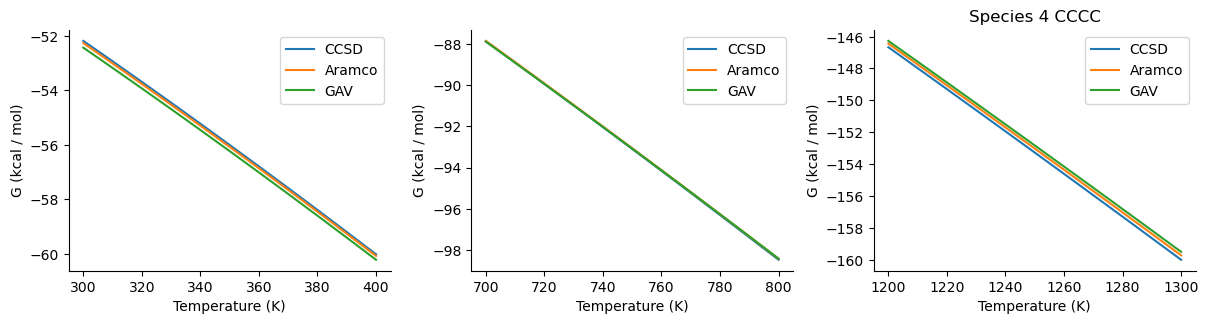

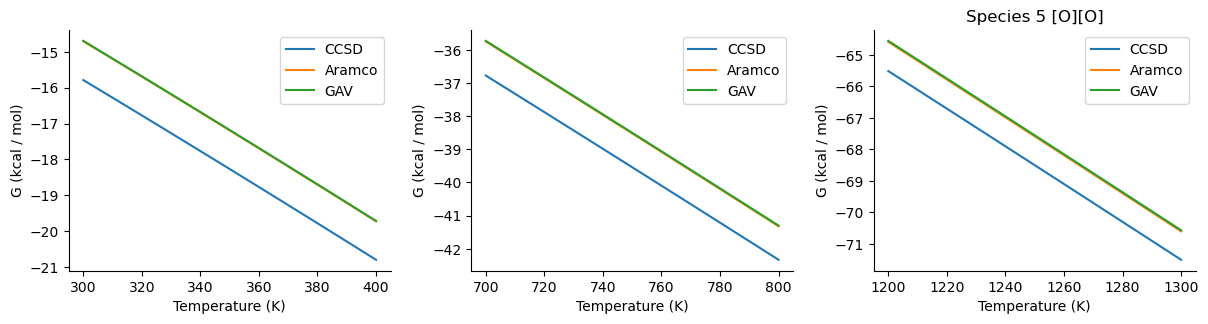

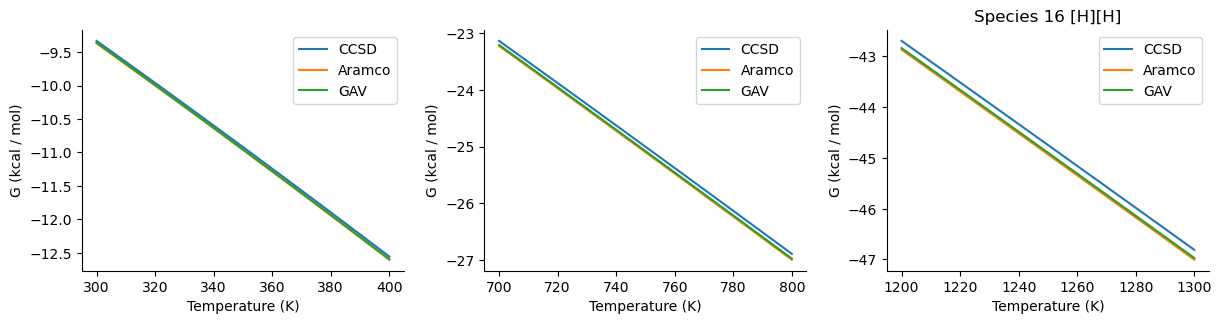

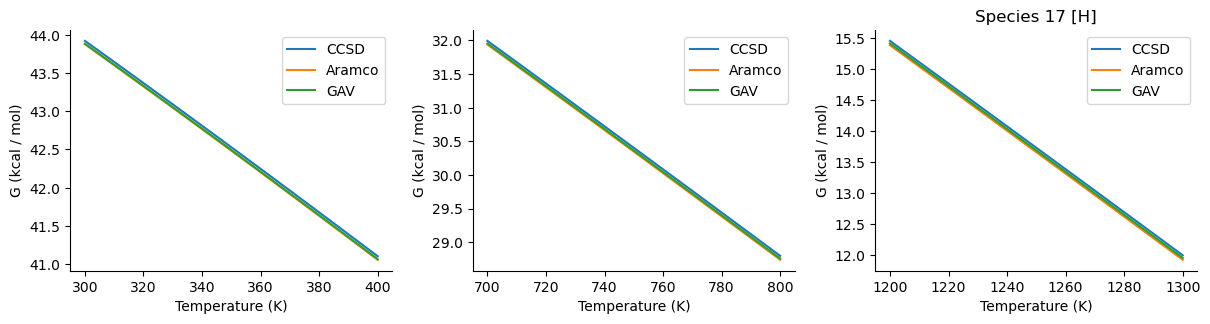

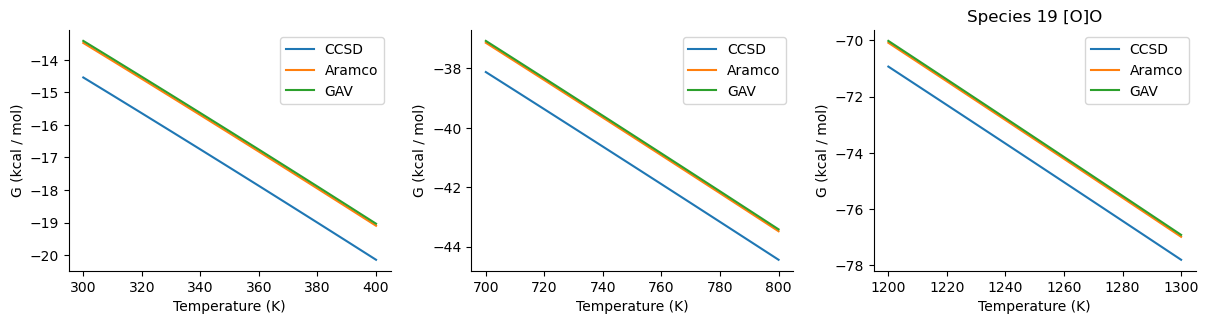

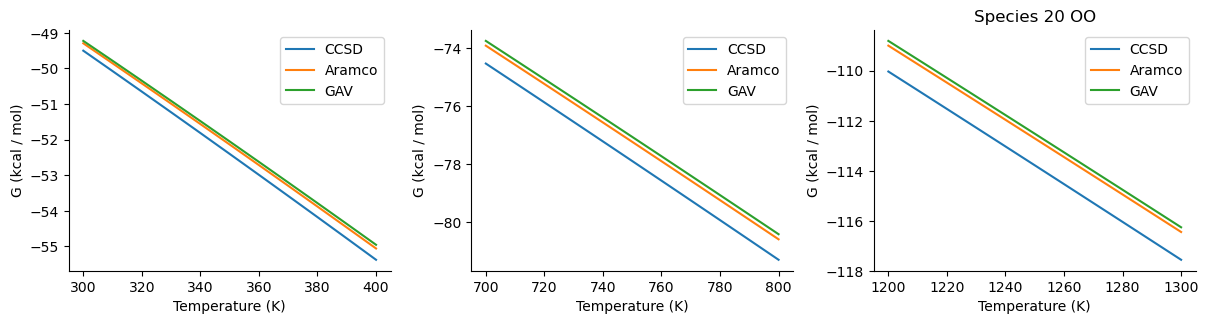

SPECIES 56 DIFFERS FROM ARAMCO!!! 1.51 kcal/mol
SPECIES 56 DIFFERS FROM GAV!!! 2.70 kcal/mol


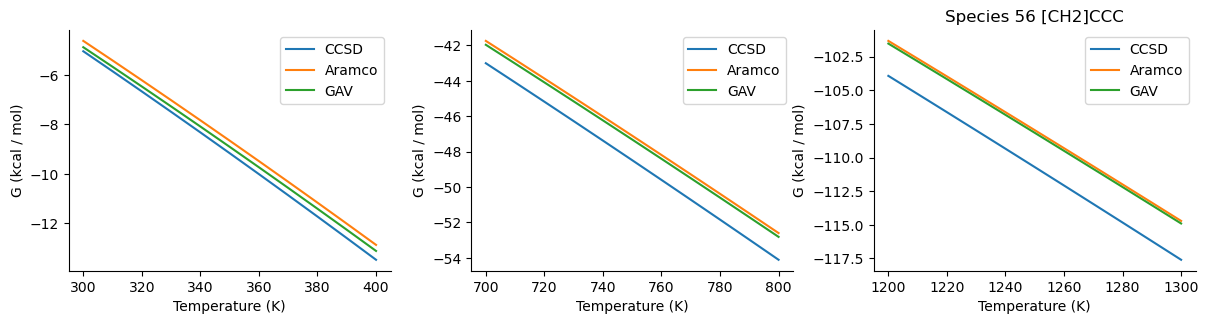

SPECIES 57 DIFFERS FROM ARAMCO!!! 1.55 kcal/mol
SPECIES 57 DIFFERS FROM GAV!!! 2.35 kcal/mol


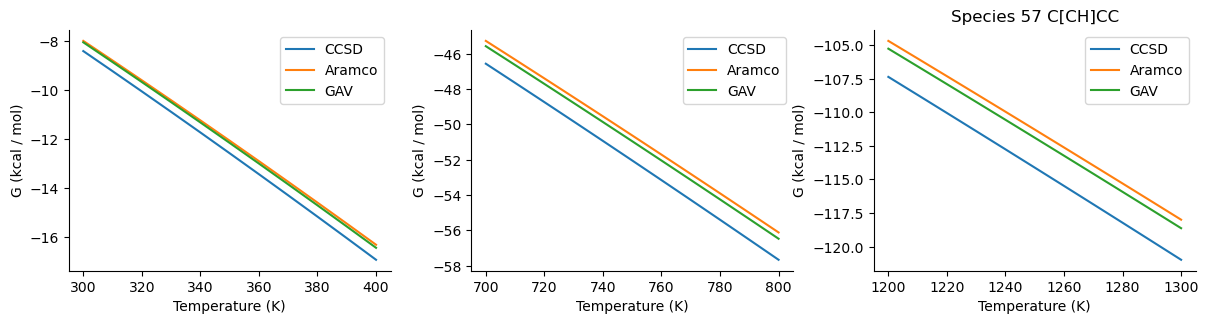

SPECIES 58 DIFFERS FROM GAV!!! 2.46 kcal/mol


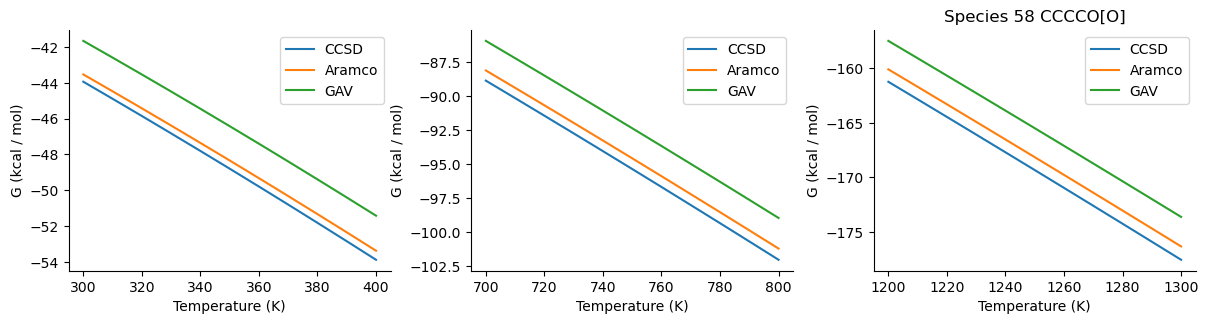

SPECIES 61 DIFFERS FROM ARAMCO!!! 1.88 kcal/mol
SPECIES 61 DIFFERS FROM GAV!!! 1.59 kcal/mol


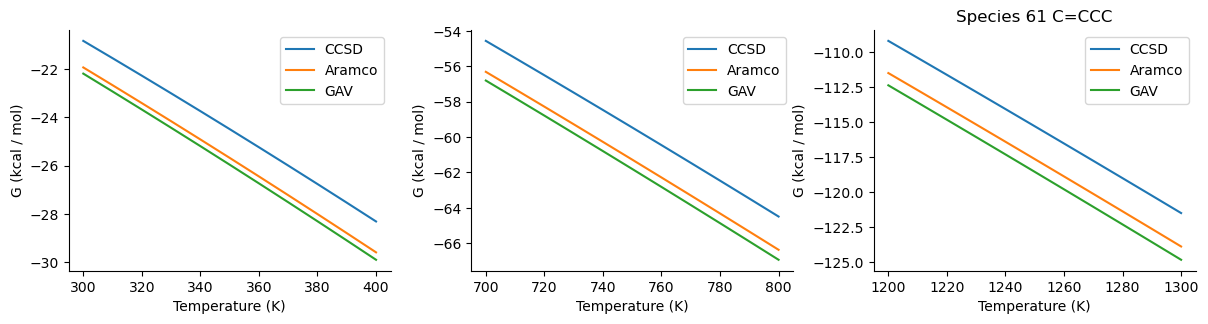

SPECIES 71 DIFFERS FROM ARAMCO!!! 2.88 kcal/mol
SPECIES 71 DIFFERS FROM GAV!!! 2.16 kcal/mol


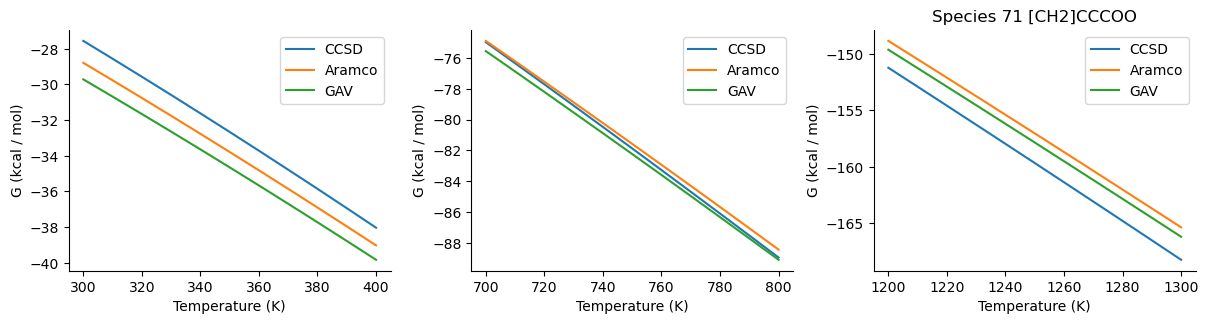

SPECIES 74 DIFFERS FROM ARAMCO!!! 2.69 kcal/mol
SPECIES 74 DIFFERS FROM GAV!!! 2.53 kcal/mol


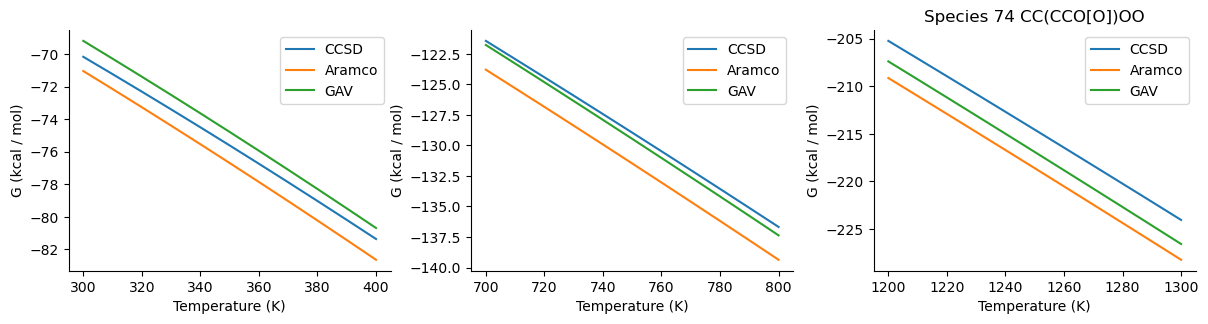

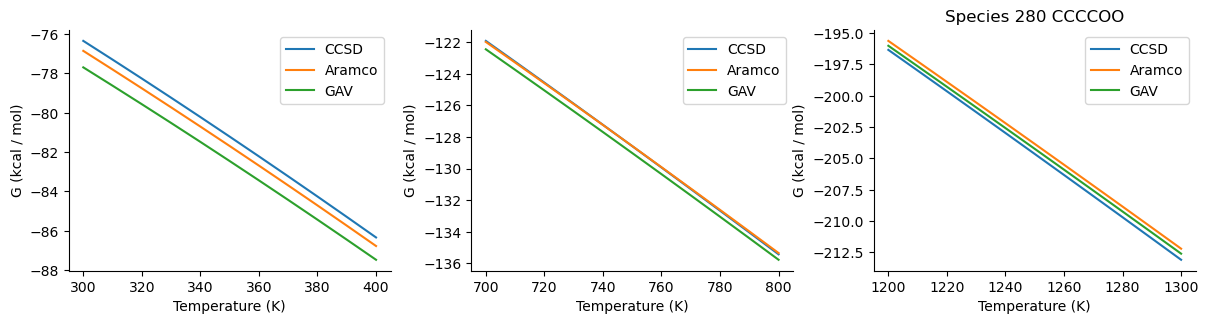

Aramco doesnt have 305
SPECIES 305 DIFFERS FROM GAV!!! 2.94 kcal/mol


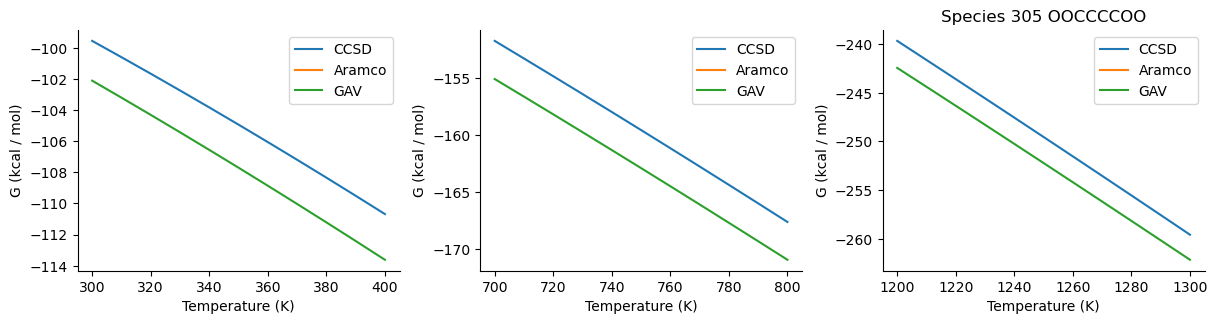

Aramco doesnt have 1113
SPECIES 1113 DIFFERS FROM GAV!!! 2.60 kcal/mol


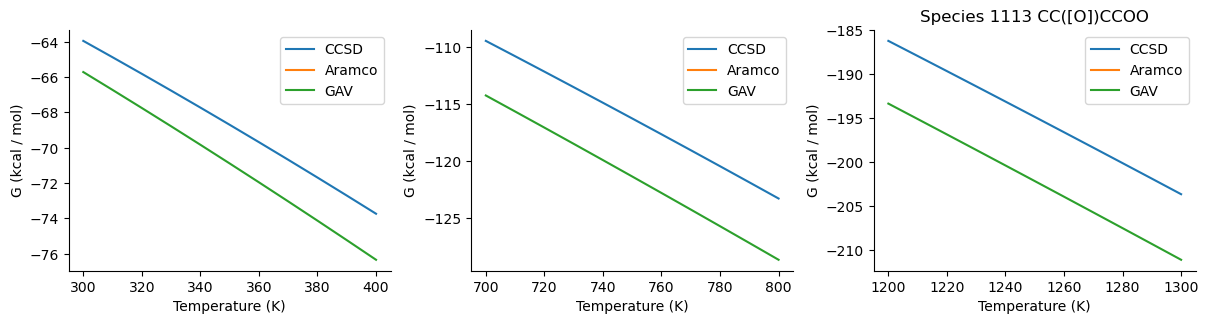

In [8]:
ARAMCO_DIFF_THRESHOLD = 1.5  # kcal/mol
GAV_DIFF_THRESHOLD = 3.0  # kcal/mol

for e in entries:
    species_index = e.index
    
    aramco_thermo = None
    indexA = get_i_thing(rmgpy.species.Species(molecule=[e.item]), species_listA)
    if indexA >= 0:
        aramco_thermo = species_listA[indexA].thermo
    else:
        print(f'Aramco doesnt have {species_index}')
    
    
    GAV_species = rmgpy.species.Species(molecule=[e.item])
    GAV_species.thermo = database.thermo.get_thermo_data(GAV_species)
    
    
    N = 11
    T_lows = np.linspace(300, 400, N)
    T_meds = np.linspace(700, 800, N)
    T_highs = np.linspace(1200, 1300, N)

    G_calc_low = np.zeros_like(T_lows)
    G_calc_med = np.zeros_like(T_meds)
    G_calc_high = np.zeros_like(T_highs)
    for j in range(N):
        G_calc_low[j] = e.data.get_free_energy(T_lows[j]) / 4184  # kcal/mol
        G_calc_med[j] = e.data.get_free_energy(T_meds[j]) / 4184  # kcal/mol
        G_calc_high[j] = e.data.get_free_energy(T_highs[j]) / 4184  # kcal/mol
        
    G_Aramco_low = np.zeros_like(T_lows) * np.nan
    G_Aramco_med = np.zeros_like(T_lows) * np.nan
    G_Aramco_high = np.zeros_like(T_lows) * np.nan
    if aramco_thermo is not None:
        for j in range(N):
            G_Aramco_low[j] = aramco_thermo.get_free_energy(T_lows[j]) / 4184  # kcal/mol
            G_Aramco_med[j] = aramco_thermo.get_free_energy(T_meds[j]) / 4184  # kcal/mol
            G_Aramco_high[j] = aramco_thermo.get_free_energy(T_highs[j]) / 4184  # kcal/mol
            
    G_GAV_low = np.zeros_like(T_lows) * np.nan
    G_GAV_med = np.zeros_like(T_lows) * np.nan
    G_GAV_high = np.zeros_like(T_lows) * np.nan
    for j in range(N):
        G_GAV_low[j] = GAV_species.thermo.get_free_energy(T_lows[j]) / 4184  # kcal/mol
        G_GAV_med[j] = GAV_species.thermo.get_free_energy(T_meds[j]) / 4184  # kcal/mol
        G_GAV_high[j] = GAV_species.thermo.get_free_energy(T_highs[j]) / 4184  # kcal/mol
        
    
    # Look for big changes
    if np.any(np.abs(G_calc_low - G_Aramco_low) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM ARAMCO!!! {np.max(np.abs(G_calc_low - G_Aramco_low)):.2f} kcal/mol')
    elif np.any(np.abs(G_calc_med - G_Aramco_med) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM ARAMCO!!! {np.max(np.abs(G_calc_med - G_Aramco_med)):.2f} kcal/mol' )
    elif np.any(np.abs(G_calc_high - G_Aramco_high) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM ARAMCO!!! {np.max(np.abs(G_calc_high - G_Aramco_high)):.2f} kcal/mol')

        
    if np.any(np.abs(G_calc_low - G_GAV_low) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM GAV!!! {np.max(np.abs(G_calc_low - G_GAV_low)):.2f} kcal/mol')
    elif np.any(np.abs(G_calc_med - G_GAV_med) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM GAV!!! {np.max(np.abs(G_calc_med - G_GAV_med)):.2f} kcal/mol')
    elif np.any(np.abs(G_calc_high - G_GAV_high) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM GAV!!! {np.max(np.abs(G_calc_high - G_GAV_high)):.2f} kcal/mol')
    
    
    
    fig, ax = plt.subplots(1, 3)
    fig.set_size_inches(12, 3)
    fig.tight_layout()
    
    
    ax[0].plot(T_lows, G_calc_low)
    ax[0].plot(T_lows, G_Aramco_low)
    ax[0].plot(T_lows, G_GAV_low)
    
    ax[1].plot(T_meds, G_calc_med)
    ax[1].plot(T_meds, G_Aramco_med)
    ax[1].plot(T_meds, G_GAV_med)
    
    ax[2].plot(T_highs, G_calc_high)
    ax[2].plot(T_highs, G_Aramco_high)
    ax[2].plot(T_highs, G_GAV_high)
    
    
    
    labels = ['CCSD', 'Aramco', 'GAV']
    for i in range(3):
        ax[i].set_xlabel('Temperature (K)')
        ax[i].set_ylabel('G (kcal / mol)')
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['top'].set_visible(False)
        ax[i].legend(labels)
    
    plt.title(f'Species {species_index} {e.label}')
    plt.subplots_adjust(wspace=0.25)
    plt.show()
    

In [12]:
k_entries

[<Entry index=213 label="HO2(16) + C[CH2](20) <=> H2O2(17) + C2H4(11)">,
 <Entry index=324 label="C4H9O4(165) <=> C4H9O4(181)">,
 <Entry index=714 label="C[CH2](20) + C=C[CH]C <=> C2H4(11) + C4H8(46)">,
 <Entry index=804 label="C[CH]CC(23) + CC(CCOO)OO(183) <=> C4H9O4(165) + butane(1)">,
 <Entry index=1111 label="CO[O](30) + C[CH2](20) <=> COO + C2H4(11)">]

Aramco doesnt have 213


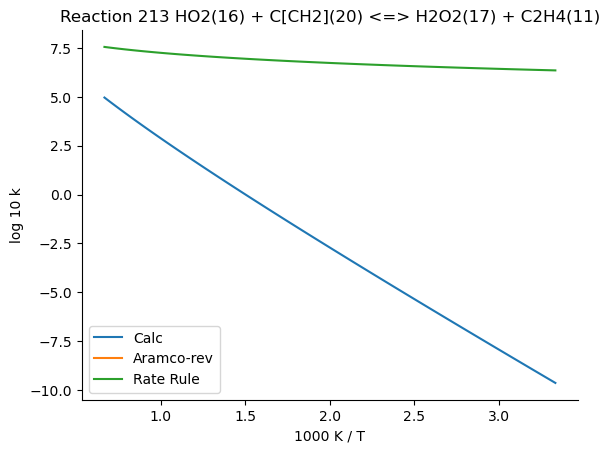

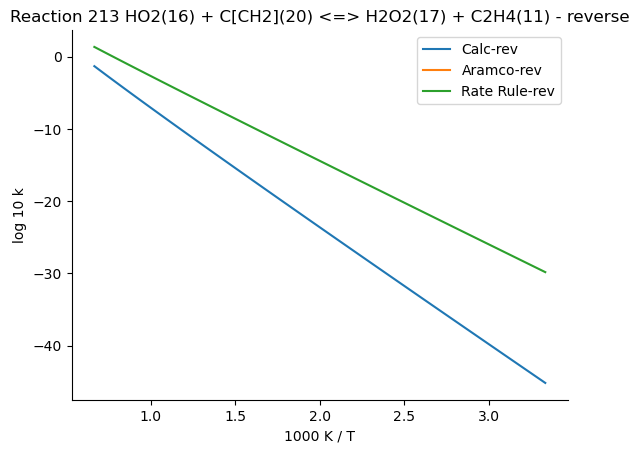

Aramco doesnt have 324


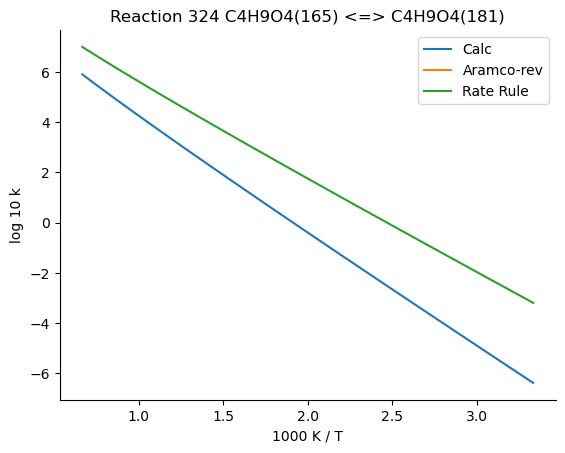

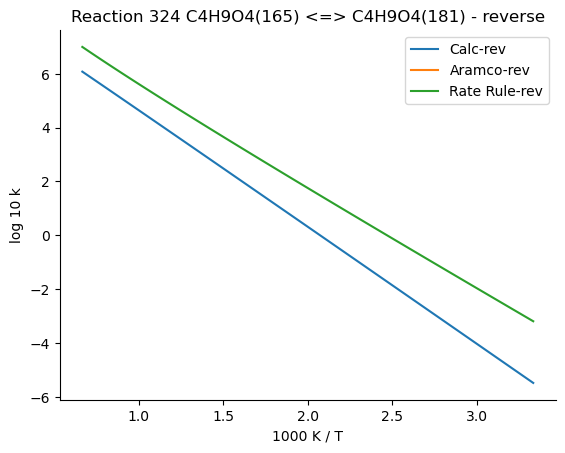

Aramco doesnt have 714
RMG-min-1 doesnt have 714


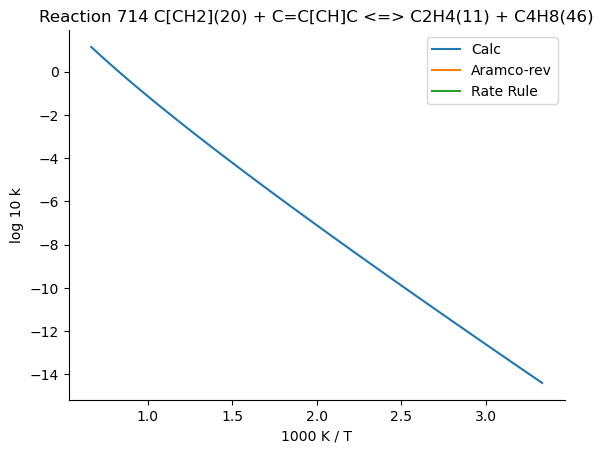

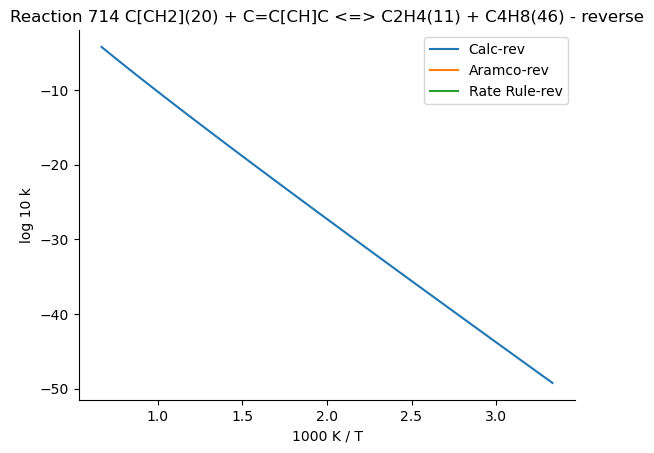

Aramco doesnt have 804


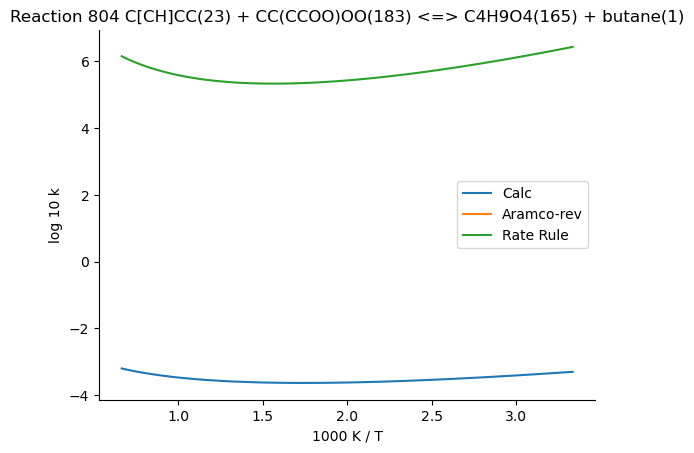

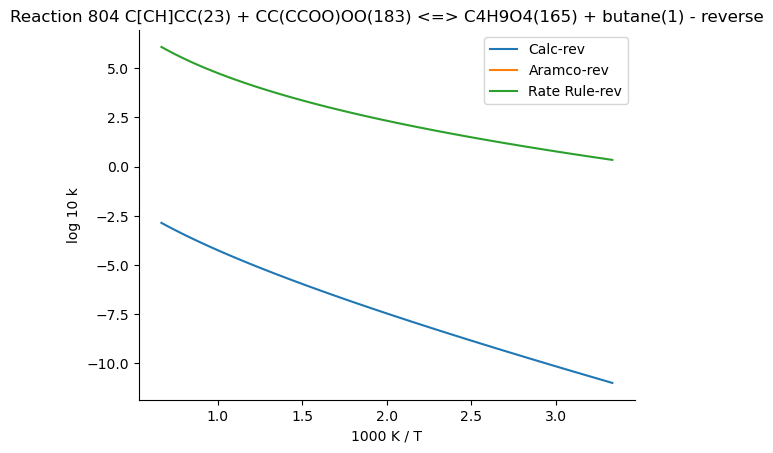

Aramco doesnt have 1111


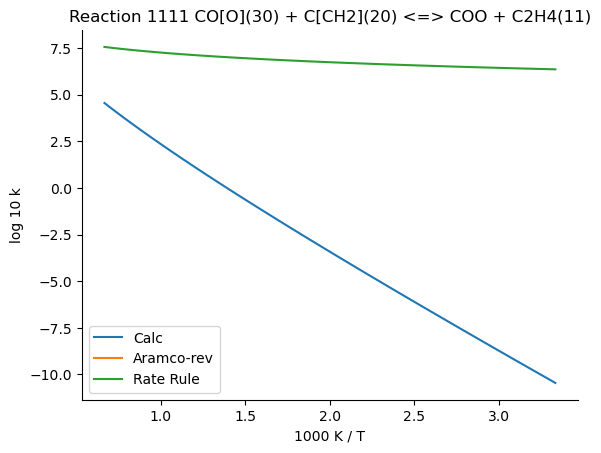

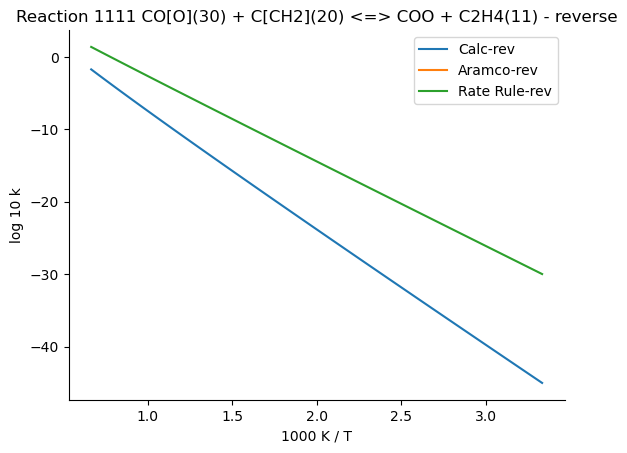

In [16]:
ARAMCO_DIFF_THRESHOLD = 2.0  # delta lnk
GAV_DIFF_THRESHOLD = 3.0  # delta lnk

N = 101
Ts = np.linspace(300, 1500, N)

for ke in k_entries:
    reaction_index = ke.index
    
    ref_rxn = rmgpy.reaction.Reaction()
    ref_rxn.reactants = ke.item.reactants
    ref_rxn.products = ke.item.products
    ref_rxn.kinetics = ke.data
    
    for i in range(len(ref_rxn.reactants)):
        j = get_i_thing(ref_rxn.reactants[i].molecule[0], [mol for mol in sp_entries])
        assert j >= 0
        ref_rxn.reactants[i].thermo = entries[j].data
    for i in range(len(ref_rxn.products)):
        j = get_i_thing(ref_rxn.products[i].molecule[0], [mol for mol in sp_entries])
        assert j >= 0
        ref_rxn.products[i].thermo = entries[j].data
    
    
    
    aramco_kinetics = None
    indexA = get_i_thing(ref_rxn, reaction_listA)
    if indexA >= 0:
        if reactions_in_same_direction(reaction_listA[indexA], ref_rxn):
            aramco_kinetics = reaction_listA[indexA].kinetics
        else:
            aramco_kinetics = get_reverse_reaction(reaction_listA[indexA]).kinetics

    else:
        print(f'Aramco doesnt have {reaction_index}')
    
    
    rate_rule_kinetics = None
    index1 = get_i_thing(ref_rxn, reaction_list1)
    if index1 >= 0:
        if reactions_in_same_direction(reaction_list1[index1], ref_rxn):
            rate_rule_kinetics = reaction_list1[index1].kinetics
        else:
            rate_rule_kinetics = get_reverse_reaction(reaction_list1[index1]).kinetics
    else:
        print(f'RMG-min-1 doesnt have {reaction_index}')
    


    k_calcs = np.zeros_like(Ts)
    for j in range(N):
        k_calcs[j] = ref_rxn.get_rate_coefficient(Ts[j])
    
    k_Aramco = np.zeros_like(Ts) * np.nan
    if aramco_kinetics is not None:
        for j in range(N):
            k_Aramco[j] = aramco_kinetics.get_rate_coefficient(Ts[j])
            
    k_rate_rule = np.zeros_like(Ts) * np.nan
    if rate_rule_kinetics is not None:
        for j in range(N):
            k_rate_rule[j] = rate_rule_kinetics.get_rate_coefficient(Ts[j])
        
    
    plt.plot(1000.0 / Ts, np.log10(k_calcs), label='Calc')
    plt.plot(1000.0 / Ts, np.log10(k_Aramco), label='Aramco-rev')
    plt.plot(1000.0 / Ts, np.log10(k_rate_rule), label='Rate Rule')
    ax = plt.gca()
    ax.set_xlabel('1000 K / T')
    ax.set_ylabel('log 10 k')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend()
    
    plt.title(f'Reaction {reaction_index} {ke.label}')
    plt.show()
    
    
    # now do the reverse
    k_calcs_rev = np.zeros_like(Ts)
    ref_rxn_rev = get_reverse_reaction(ref_rxn)
    for j in range(N):
        k_calcs_rev[j] = ref_rxn_rev.get_rate_coefficient(Ts[j])
    
    k_Aramco_rev = np.zeros_like(Ts) * np.nan
    aramco_rev = get_reverse_reaction(reaction_listA[indexA])
    if aramco_kinetics is not None:
        for j in range(N):
            k_Aramco_rev[j] = aramco_rev.get_rate_coefficient(Ts[j])
            
    k_rate_rule_rev = np.zeros_like(Ts) * np.nan
    rate_rule_rev = get_reverse_reaction(reaction_list1[index1])
    if rate_rule_kinetics is not None:
        for j in range(N):
            k_rate_rule_rev[j] = rate_rule_rev.get_rate_coefficient(Ts[j])
        
    
    plt.plot(1000.0 / Ts, np.log10(k_calcs_rev), label='Calc-rev')
    plt.plot(1000.0 / Ts, np.log10(k_Aramco_rev), label='Aramco-rev')
    plt.plot(1000.0 / Ts, np.log10(k_rate_rule_rev), label='Rate Rule-rev')
    
    
#     labels = ['CCSD', 'Aramco', 'GAV']
    ax = plt.gca()
    ax.set_xlabel('1000 K / T')
    ax.set_ylabel('log 10 k')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend()
    
    plt.title(f'Reaction {reaction_index} {ke.label} - reverse')
    plt.show()
    

In [13]:
ke.label

'HO2(16) + C[CH]CC(23) <=> O2(2) + butane(1)'

In [14]:
e.data

Arrhenius(A=(3.30984,'cm^3/(mol*s)'), n=3.3901, Ea=(-22.9691,'kJ/mol'), T0=(1,'K'), Tmin=(298,'K'), Tmax=(2500,'K'), comment="""Fitted to 50 data points; dA = *|/ 1.23623, dn = +|- 0.0278609, dEa = +|- 0.151618 kJ/mol""")

Text(0, 0.5, 'Gibbs energy kcal/mol')

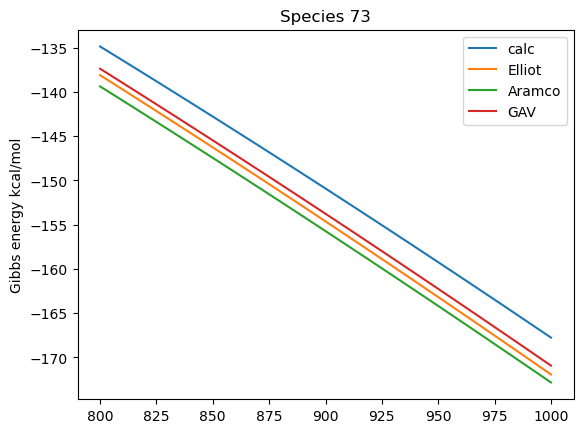

In [38]:
# Check on the Eliot thermo
# aNBT1O2H-3O2  #73
sp_73_entry = """aNBT1O2H-3O2            C   4H   9O   4     G     200.0    3000.0  1000.0      1
 1.39835569E+01 3.75477941E-02-1.93260905E-05 4.78659185E-09-4.63531574E-13    2
-2.49626475E+04-3.69803036E+01 9.34257949E+00 3.20409232E-02 3.44070209E-05    3
-7.00254165E-08 3.07632136E-11-2.30216188E+04-9.15060250E+00                   4"""

species, sp_73_elliot_thermo, formula = rmgpy.chemkin.read_thermo_entry(sp_73_entry)

sp_73_calc_thermo = [e.data for e in entries if e.index == 73][0]

ref73 = database_fun.index2species(73)

aramco_73_thermo = species_listA[get_i_thing(ref73, species_listA)]
GAV_73_thermo = database.thermo.get_thermo_data(ref73)

Ts = np.linspace(800, 1000, 101)
# Ts = np.linspace(300, 800, 101)
Gs = np.zeros_like(Ts)
Gs_elliot = np.zeros_like(Ts)
Gs_GAV = np.zeros_like(Ts)
Gs_aramco = np.zeros_like(Ts)
for j in range(len(Ts)):
    Gs[j] = sp_73_calc_thermo.get_free_energy(Ts[j]) / 4184  # kcal/mol
    Gs_elliot[j] = sp_73_elliot_thermo.get_free_energy(Ts[j]) / 4184
    Gs_aramco[j] = aramco_73_thermo.get_free_energy(Ts[j]) / 4184
    Gs_GAV[j] = GAV_73_thermo.get_free_energy(Ts[j]) / 4184
    
plt.plot(Ts, Gs, label='calc')
plt.plot(Ts, Gs_elliot, label='Elliot')
plt.plot(Ts, Gs_aramco, label='Aramco')
plt.plot(Ts, Gs_GAV, label='GAV')
plt.legend()
plt.title('Species 73')
plt.ylabel('Gibbs energy kcal/mol')

In [27]:
np.max(np.abs(Gs_elliot - Gs))

5.434171594161796

ERROR:root:Cairo not found; molecule will not be drawn.


FileNotFoundError: [Errno 2] No such file or directory: 'temp_reaction.png'

Reaction(reactants=[Species(label="C4H9O4(165)", molecule=[Molecule(smiles="CC(CCO[O])OO")], molecular_weight=(121.112,'amu'))], products=[Species(label="C4H9O4(181)", molecule=[Molecule(smiles="CC(CCOO)O[O]")], molecular_weight=(121.112,'amu'))], elementary_high_p=True,)

In [9]:
chemkin_file1 = '/work/westgroup/harris.se/autoscience/fuels/butane/RMG_min/butane_20241219/chem_annotated.inp'
dict_file1 = '/work/westgroup/harris.se/autoscience/fuels/butane/RMG_min/butane_20241219/species_dictionary.txt'
species_list1, reaction_list1 = rmgpy.chemkin.load_chemkin_file(chemkin_file1, dict_file1)

In [14]:
print(reaction_list1[98])

CC(CCOO)O[O](160) <=> CC(CCO[O])OO(144)


In [16]:
reaction_list1[98].kinetics

Arrhenius(A=(474158,'s^-1'), n=1.155, Ea=(16.101,'kcal/mol'), T0=(1,'K'), comment="""Estimated using template [R7H_OOCs4;O_rad_out;XH_out] for rate rule [R7H_OOCs4;O_rad_out;O_H_out]
Euclidian distance = 1.0
family: intra_H_migration""")

In [17]:
reactions_in_same_direction(k_entries[0].item, reaction_list1[98])

False

In [20]:
# reactions_in_same_direction(k_entries[0].item, reaction_list1[98])

r1 = get_reverse_reaction(reaction_list1[98])

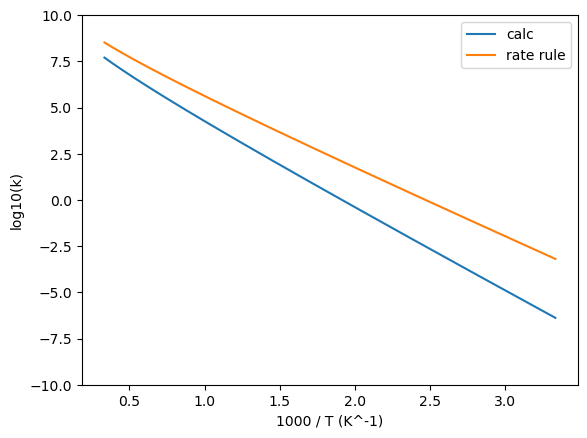

In [21]:
plot_kinetics([k_entries[0].data, r1], ['calc', 'rate rule'])

In [ ]:
plot_kinetics([k_entries[0].data, r1], ['calc', 'rate rule'])

In [ ]:
aramco_kinetics

In [ ]:
get_reaction_species(4721)